In [11]:
from pathlib import Path
from typing import List, Sequence, Optional, Any, Tuple
from plotnine import (
	ggplot,
	aes,
	geom_path,
	geom_point,
	ggtitle,
	xlab,
	ylab,
	theme,
	element_text,
	element_rect,
 	element_line
)
from plotnine.themes import theme_classic
import plotnine.scales as scales
import polars as pl
import pandas as pd


In [40]:
# --- Load Excel file ---
def load_file(file_name: str, sheet_name= None) -> pl.DataFrame:
    
    """Load an Excel file as a DataFrame with a fast engine for processing Excel files.
    Parameters:
    - file_name
    - sheet_name: Excel sheet required or None to load the first sheet
    Returns a pandas DataFrame"""
    
    # 1. Get the folder where THIS script lives
    script_location = Path.cwd()
    
    # 2. Build the path to the file relative to the script
    file_path = script_location / "Data" / file_name
    
    path = Path(file_path)
    if not path.exists():
        raise FileNotFoundError(f'File not found: {file_path}')
    # Let pandas choose a working engine (openpyxl, xlrd, etc.). If your environment requires a specific engine, pass it here.
    df = pl.read_excel(path, sheet_name=sheet_name, engine="calamine")
    df.columns = [
    c.strip()
    .replace(" (", "(")   # <--- Removes space before (
    .replace(" ", "_")    # <--- Turns remaining spaces to underscores
    for c in df.columns
    ]
    return df

In [41]:
# Example:
df = load_file("LFP/LFP_2nd_Test/moha_LFP_grad5C_14mg_Channel_6_Wb_1.xlsx", "Channel-6_1")
df.head()

Could not determine dtype for column 15, falling back to string


Data_Point,Date_Time,Test_Time(s),Step_Time(s),Cycle_Index,Step_Index,Current(A),Voltage(V),Power(W),Charge_Capacity(Ah),Discharge_Capacity(Ah),Charge_Energy(Wh),Discharge_Energy(Wh),Capacity(Ah),mAh/g,ACR(Ohm),dV/dt(V/s),Internal_Resistance(Ohm),dQ/dV(Ah/V),dV/dQ(V/Ah)
i64,str,f64,f64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,i64,str,f64,i64,f64,f64
1,"""11/20/2025 18:40:58.968""",60.0005,60.0005,1,1,0.0,3.132666,0.0,0.0,0.0,0.0,0.0,0.0,0,null,0.000007,null,null,null
2,"""11/20/2025 18:41:58.968""",120.0004,120.0004,1,1,0.0,3.132422,0.0,0.0,0.0,0.0,0.0,0.0,0,null,-0.000012,null,null,null
3,"""11/20/2025 18:42:58.968""",180.0003,180.0003,1,1,0.0,3.132203,0.0,0.0,0.0,0.0,0.0,0.0,0,null,-0.000008,null,0.0,0.0
4,"""11/20/2025 18:43:58.968""",240.0002,240.0002,1,1,0.0,3.132051,0.0,0.0,0.0,0.0,0.0,0.0,0,null,-0.000016,null,null,null
5,"""11/20/2025 18:44:58.967""",300.0001,300.0001,1,1,0.0,3.131883,0.0,0.0,0.0,0.0,0.0,0.0,0,null,-0.000026,null,0.0,0.0


In [65]:
def edit_excel(active_m: float, df: pl.DataFrame, export_excel: bool, path: str = None) -> pl.DataFrame:
    
    # Add computed columns in one call (casts for safety)
    df = df.drop("Internal_Resistance(Ohm)", "ACR(Ohm)")
    df = df.with_columns([
        (pl.col("Step_Time(s)").cast(pl.Float64) / 3600).alias("Time(h)"),
        (abs((pl.col("Step_Time(s)").cast(pl.Float64) / 3600) * pl.col("Current(A)").cast(pl.Float64) * 1000 / active_m))
            .alias("Specific_Capacity(mAh/g)"),
        (pl.col("dQ/dV(Ah/V)").cast(pl.Float64) * 1000 / active_m).alias("Specific_dQ/dV")
        ])

    if export_excel:
        # Save: prefer pandas fallback for broad compatibility
        df.to_pandas().to_excel(path if path is not None else "Edited_Excel.xlsx", index=False)
    
    return df
#df = load_file("LFP/LFP_2nd_Test/moha_LFP_grad5C_14mg_Channel_6_Wb_1.xlsx", "Channel-6_1")
#df = edit_excel(0.0031, df, export_excel=False)


In [19]:
#df.head()

In [57]:
# --- Filtering function ---
def filtering(df: pl.DataFrame, filter_column_names: Sequence[str], ranges: Sequence[Sequence[Any]]) -> pl.DataFrame:
    """Filter `df` by multiple columns using membership tests (isin).
    - `filter_column_names`: sequence of column names to filter on
    - `ranges`: sequence of sequences containing allowed values for each corresponding column
    Returns the filtered DataFrame."""
    if len(filter_column_names) != len(ranges):
        raise ValueError('filter_column_names and ranges must have the same length')
    
    # Use lazy execution for better performance on chains of filters
    lf = df.lazy()
    
    for col, criteria in zip(filter_column_names, ranges):
        if col not in df.columns:
            raise KeyError(f"Column '{col}' not found in DataFrame")
        
        # LOGIC CHANGE: Check type of 'criteria'
        if isinstance(criteria, tuple) and len(criteria) == 2:
            # If it's a tuple (min, max), use is_between
            # accurate for "around 2.5" logic
            lower_bound, upper_bound = criteria
            lf = lf.filter(pl.col(col).is_between(lower_bound, upper_bound))
        else:
            # If it's a list/sequence, use standard is_in
            lf = lf.filter(pl.col(col).is_in(criteria))
        
    return lf.collect()

In [ ]:
#Plotting Specific_dQ/dV vs Voltage(V)
def spec_dQdV_df(df: pl.DataFrame, range: Sequence[Sequence[int]]) -> pl.DataFrame:
    """Prepare DataFrame for plotting Specific_dQ/dV vs Voltage(V).
    Filters for Cycle_Index 1 and Step_Index 2 or 3, adjusts Specific_dQ/dV sign for discharge steps.
    Returns the modified DataFrame."""
    
    discharge_steps = range[1][1::2]  # Define discharge steps
    
    df_sp_dQdV = filtering(df, ["Cycle_Index", "Step_Index"], range)

    df_sp_dQdV = df_sp_dQdV.filter(pl.col("Specific_dQ/dV").is_not_null() &
                                (pl.col("Specific_dQ/dV").is_not_nan()) &
                                (pl.col("Specific_dQ/dV") != 0)
                                )
    
    df_sp_dQdV = df_sp_dQdV.with_columns(
                            pl.when((pl.col("Step_Index").is_in(discharge_steps)))
                            .then(pl.col("Specific_dQ/dV") * -1)
                            .otherwise(pl.col("Specific_dQ/dV"))
                            .alias("Specific_dQ/dV")  # Ensures it overwrites the original column
                            )
    
    df_sp_dQdV = df_sp_dQdV.filter(pl.col("dQ/dV(Ah/V)").is_not_null() &
                                (pl.col("dQ/dV(Ah/V)").is_not_nan()) &
                                (pl.col("dQ/dV(Ah/V)") != 0)
                                )
    
    df_sp_dQdV = df_sp_dQdV.with_columns(
                            pl.when((pl.col("Step_Index").is_in(discharge_steps)))
                            .then(pl.col("dQ/dV(Ah/V)") * -1)
                            .otherwise(pl.col("dQ/dV(Ah/V)"))
                            .alias("dQ/dV(Ah/V)")  # Ensures it overwrites the original column
                            )
    return df_sp_dQdV

SyntaxError: '(' was never closed (3329334495.py, line 28)

In [59]:
def plotnine_ploting(
    df: pl.DataFrame,
    multiple_graphs: bool = True,
    show_legend: bool = True,
    points_and_lines: int = 0,
    column_filter: Optional[str] = 'Cycle_Index',
    column_x: str = 'Cycle_Index',
    column_y: str = 'Specific Capacity (mAh/g)',
    plot_title: str = 'Plot',
    folder_name: str = 'default',
    markevery: int = 1,
    save_base: str = 'Cycling/plots',
    overwrite: bool = False,
    dpi: int = 400,
    width: float = 8,
    height: float = 6,
    units: str = 'in')-> Tuple[str, str]:
    
    # Convert to pandas for plotnine
    df = pd.DataFrame(df.to_pandas())
        
    # Determine if grouping should be applied
    use_grouping = column_filter in df.columns if column_filter else False
    
    # Prepare grouping column if present
    if use_grouping:
        df[column_filter] = df[column_filter].astype('category')

    # Build ggplot using aes_string for dynamic column names
    # Base ggplot mapping
    aes_mapping = dict(x=column_x, y=column_y)
    
    if multiple_graphs and use_grouping:
        aes_mapping.update(color=column_filter, group=column_filter)
    gg = ggplot(df, aes(**aes_mapping))

    # Sample points for markers
    if markevery > 1:
        if multiple_graphs and use_grouping:
            point_df = (df.assign(_idx=df.groupby(column_filter, observed=True).cumcount()).loc[lambda d: d["_idx"] % markevery == 0].drop(columns="_idx"))
        else:
            point_df = df.iloc[::markevery].copy()
    else:
        point_df = df.copy()

    # Define layers
    layers = []
    if points_and_lines in [0, 2]:
        layers.append(geom_path(size=0.8))  # Slightly thicker line for publications
    if points_and_lines in [1, 2]:
        layers.append(geom_point(data=point_df, size=4, stroke=0.5))  # Larger points for visibility
    for layer in layers:
        gg = gg + layer

    # Colormap for multiple graphs
    if multiple_graphs and use_grouping:
        gg = gg + scales.scale_colour_discrete()


    gg = (gg + ggtitle(plot_title)
          + xlab(column_x)
          + ylab(column_y)
          + theme_classic(base_size=12)
          + theme(                  
                axis_text=element_text(size=12),
                axis_title=element_text(size=12),
                plot_title=element_text(size=12, weight='bold'),
                legend_position='right' if show_legend else 'none',
                panel_background=element_rect(fill='lightgray'),
                panel_border=element_rect(color='black', size=1.5),
                figure_size=(width, height),
                panel_grid_major=element_line(color="white", size=0.7),
                panel_grid_minor=element_line(color="white", size=0.25),
         ))

    if not show_legend:
        gg = gg + theme(legend_position='none')
    
    gg.show()
    # Prepare save paths
    save_folder = Path(save_base) / folder_name
    save_folder.mkdir(parents=True, exist_ok=True)
    safe_title = plot_title.replace(' ', '_').replace('/', '_')
    save_paths = {
        'PNG': save_folder / f"{safe_title}.png",
        'PDF': save_folder / f"{safe_title}.pdf"
    }

    # Save files
    for fmt, path in save_paths.items():
        if path.exists() and not overwrite:
            print(f"Skipping existing {fmt} (overwrite=False): {path}")
        else:
            gg.save(str(path), dpi=dpi if fmt == 'PNG' else None, width=width, height=height, units=units)
            print(f"{fmt} saved to {path}")

    return str(save_paths['PNG']), str(save_paths['PDF'])

In [60]:
def build_selected_cycles(df: pl.DataFrame, start: Tuple[int, int], mid: int, end: Tuple[int, int]) -> List[int]:
    cycles = sorted(df['Cycle_Index'].unique())
    return sorted(set(cycles[start[0]:start[1]] + [c for c in cycles if c % mid == 0] + cycles[end[0]:end[1]]))

Could not determine dtype for column 15, falling back to string


Selected cycles: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


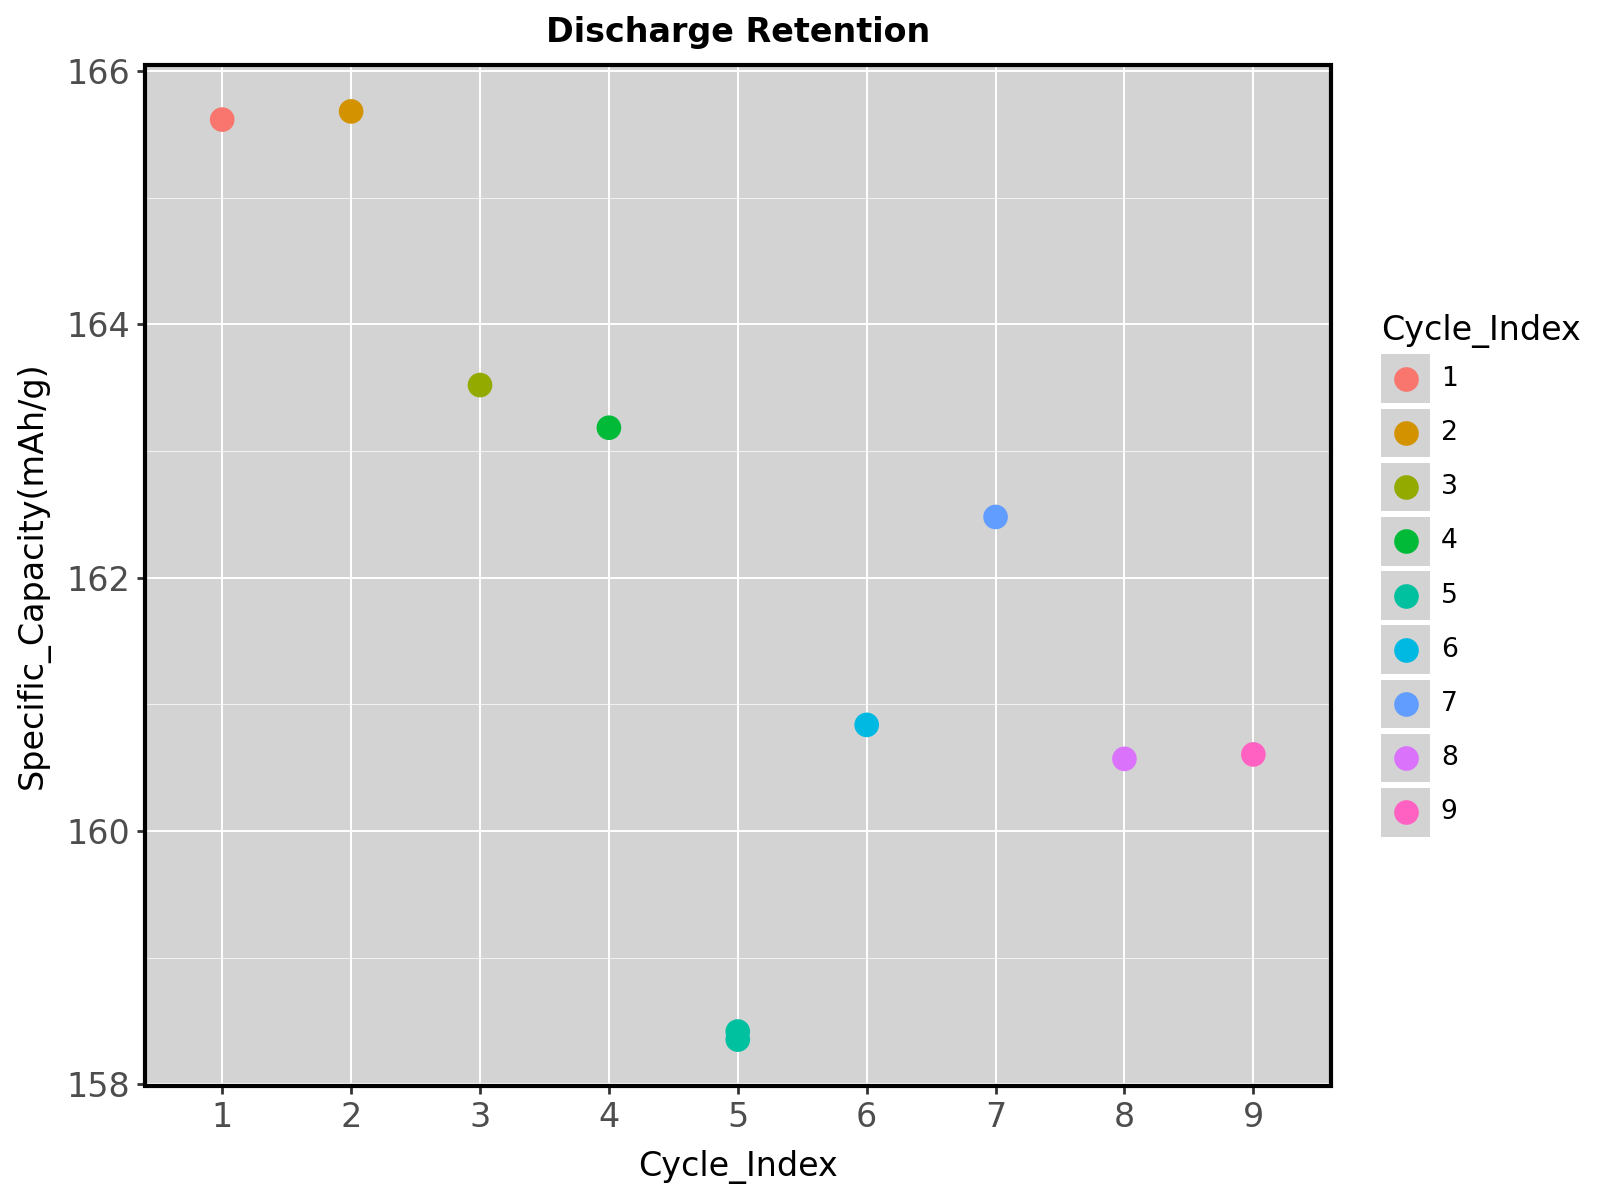

c:\Users\MTP24ME\AppData\Local\Programs\Python\Python312\Lib\site-packages\plotnine\ggplot.py:623: PlotnineWarning: Saving 8 x 6 in image.
c:\Users\MTP24ME\AppData\Local\Programs\Python\Python312\Lib\site-packages\plotnine\ggplot.py:624: PlotnineWarning: Filename: Cycling\plots\LFP_grad5C_14\Discharge_Retention.png


PNG saved to Cycling\plots\LFP_grad5C_14\Discharge_Retention.png
PDF saved to Cycling\plots\LFP_grad5C_14\Discharge_Retention.pdf


c:\Users\MTP24ME\AppData\Local\Programs\Python\Python312\Lib\site-packages\plotnine\ggplot.py:623: PlotnineWarning: Saving 8 x 6 in image.
c:\Users\MTP24ME\AppData\Local\Programs\Python\Python312\Lib\site-packages\plotnine\ggplot.py:624: PlotnineWarning: Filename: Cycling\plots\LFP_grad5C_14\Discharge_Retention.pdf


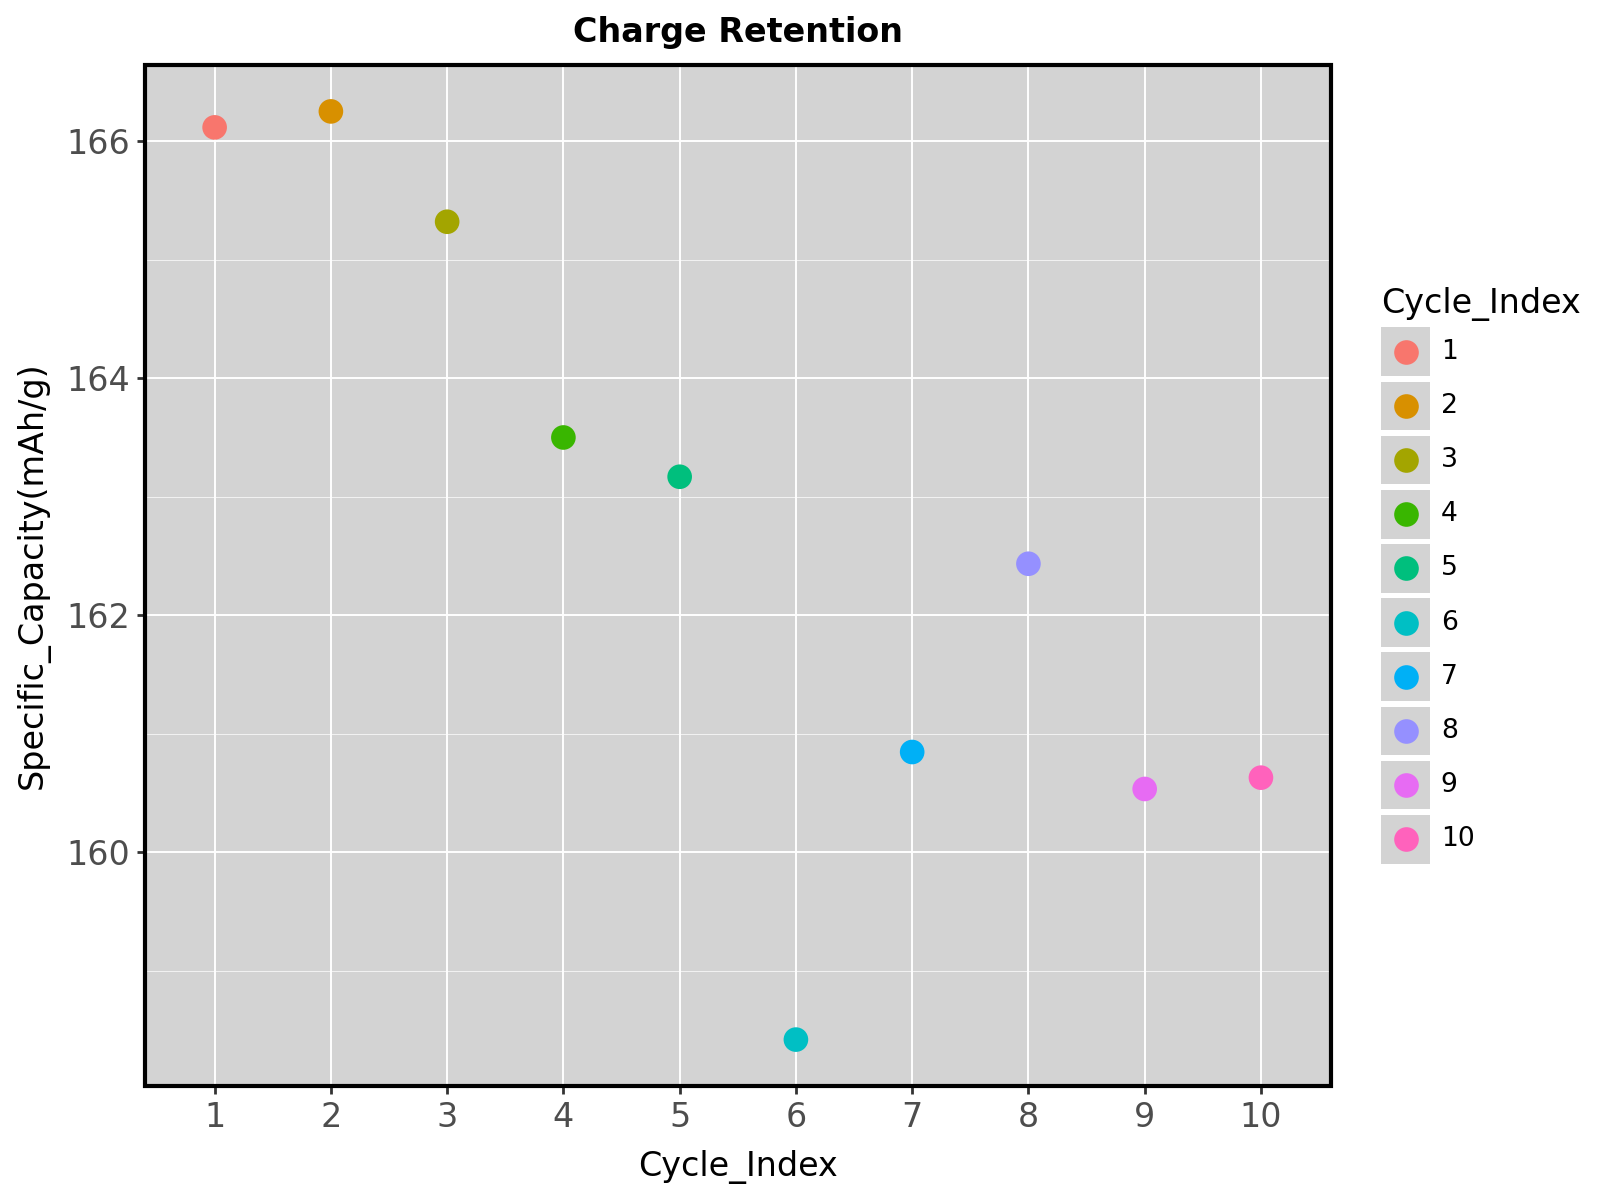

c:\Users\MTP24ME\AppData\Local\Programs\Python\Python312\Lib\site-packages\plotnine\ggplot.py:623: PlotnineWarning: Saving 8 x 6 in image.
c:\Users\MTP24ME\AppData\Local\Programs\Python\Python312\Lib\site-packages\plotnine\ggplot.py:624: PlotnineWarning: Filename: Cycling\plots\LFP_grad5C_14\Charge_Retention.png


PNG saved to Cycling\plots\LFP_grad5C_14\Charge_Retention.png
PDF saved to Cycling\plots\LFP_grad5C_14\Charge_Retention.pdf


c:\Users\MTP24ME\AppData\Local\Programs\Python\Python312\Lib\site-packages\plotnine\ggplot.py:623: PlotnineWarning: Saving 8 x 6 in image.
c:\Users\MTP24ME\AppData\Local\Programs\Python\Python312\Lib\site-packages\plotnine\ggplot.py:624: PlotnineWarning: Filename: Cycling\plots\LFP_grad5C_14\Charge_Retention.pdf


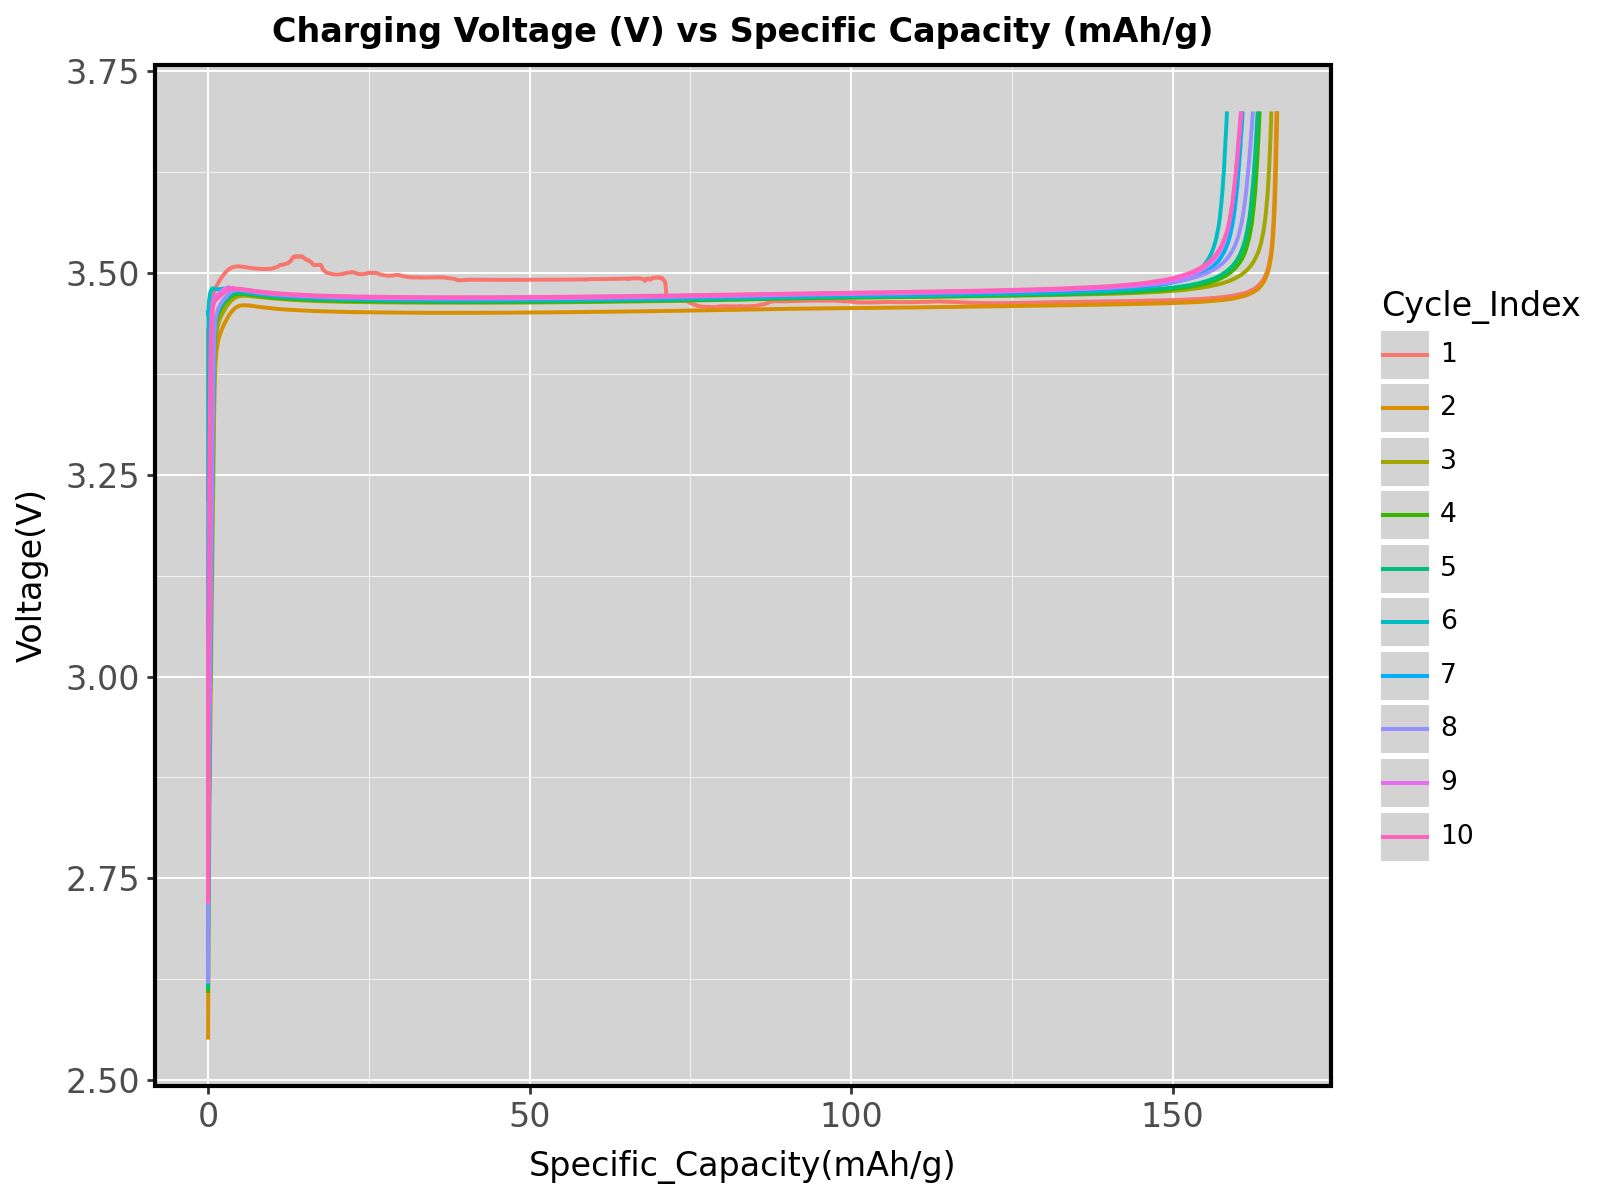

c:\Users\MTP24ME\AppData\Local\Programs\Python\Python312\Lib\site-packages\plotnine\ggplot.py:623: PlotnineWarning: Saving 8 x 6 in image.
c:\Users\MTP24ME\AppData\Local\Programs\Python\Python312\Lib\site-packages\plotnine\ggplot.py:624: PlotnineWarning: Filename: Cycling\plots\LFP_grad5C_14\Charging_Voltage_(V)_vs_Specific_Capacity_(mAh_g).png


PNG saved to Cycling\plots\LFP_grad5C_14\Charging_Voltage_(V)_vs_Specific_Capacity_(mAh_g).png


c:\Users\MTP24ME\AppData\Local\Programs\Python\Python312\Lib\site-packages\plotnine\ggplot.py:623: PlotnineWarning: Saving 8 x 6 in image.
c:\Users\MTP24ME\AppData\Local\Programs\Python\Python312\Lib\site-packages\plotnine\ggplot.py:624: PlotnineWarning: Filename: Cycling\plots\LFP_grad5C_14\Charging_Voltage_(V)_vs_Specific_Capacity_(mAh_g).pdf


PDF saved to Cycling\plots\LFP_grad5C_14\Charging_Voltage_(V)_vs_Specific_Capacity_(mAh_g).pdf


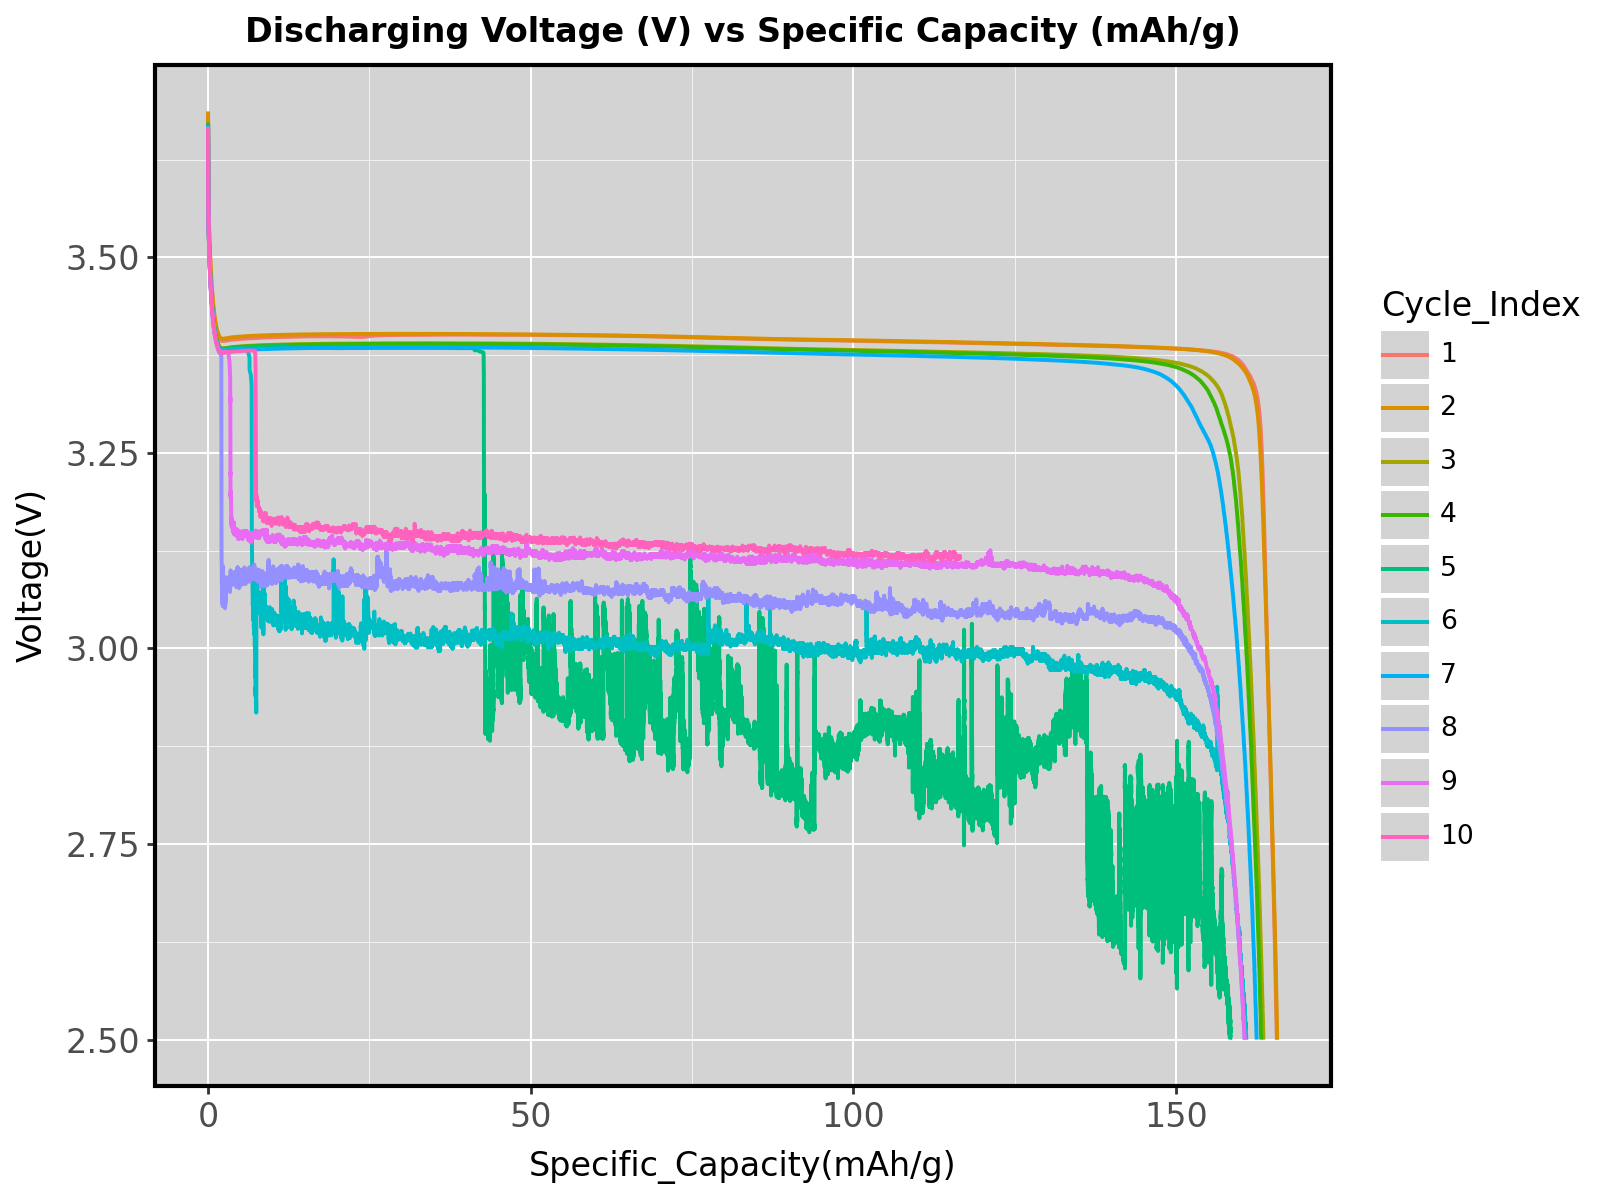

c:\Users\MTP24ME\AppData\Local\Programs\Python\Python312\Lib\site-packages\plotnine\ggplot.py:623: PlotnineWarning: Saving 8 x 6 in image.
c:\Users\MTP24ME\AppData\Local\Programs\Python\Python312\Lib\site-packages\plotnine\ggplot.py:624: PlotnineWarning: Filename: Cycling\plots\LFP_grad5C_14\Discharging_Voltage_(V)_vs_Specific_Capacity_(mAh_g).png


PNG saved to Cycling\plots\LFP_grad5C_14\Discharging_Voltage_(V)_vs_Specific_Capacity_(mAh_g).png


c:\Users\MTP24ME\AppData\Local\Programs\Python\Python312\Lib\site-packages\plotnine\ggplot.py:623: PlotnineWarning: Saving 8 x 6 in image.
c:\Users\MTP24ME\AppData\Local\Programs\Python\Python312\Lib\site-packages\plotnine\ggplot.py:624: PlotnineWarning: Filename: Cycling\plots\LFP_grad5C_14\Discharging_Voltage_(V)_vs_Specific_Capacity_(mAh_g).pdf


PDF saved to Cycling\plots\LFP_grad5C_14\Discharging_Voltage_(V)_vs_Specific_Capacity_(mAh_g).pdf


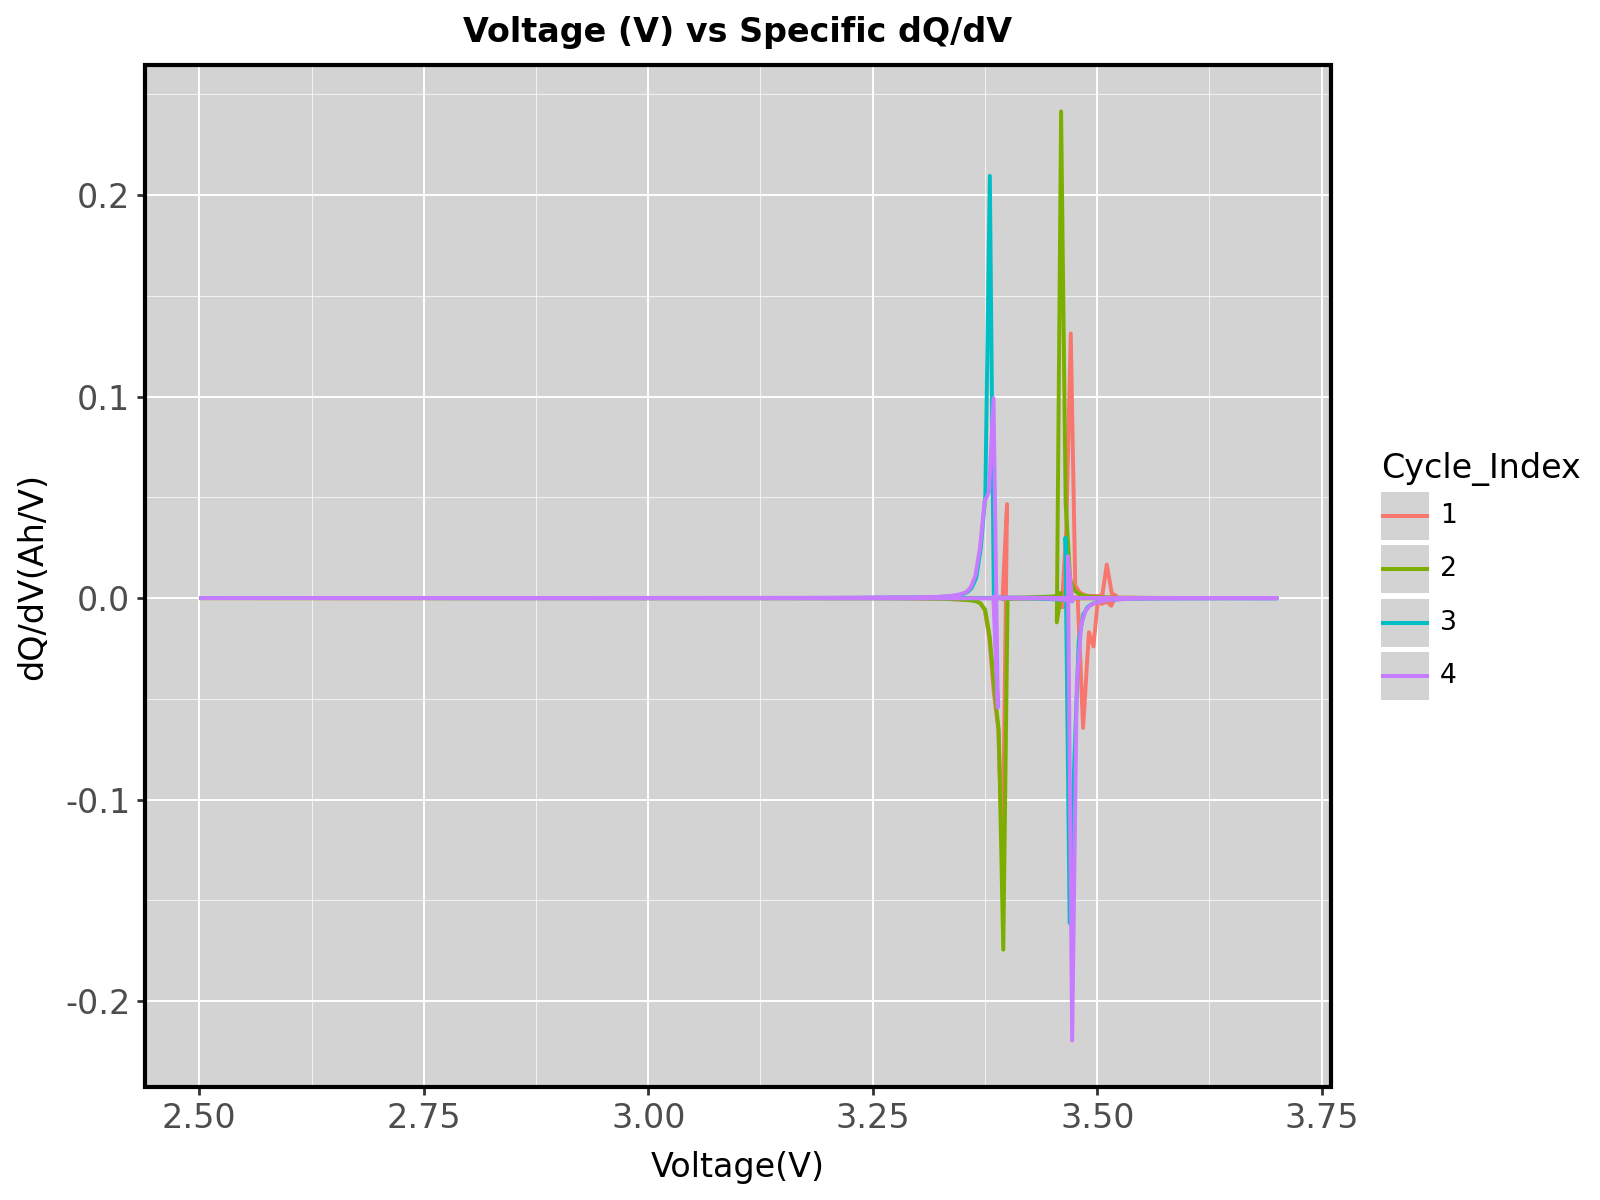

c:\Users\MTP24ME\AppData\Local\Programs\Python\Python312\Lib\site-packages\plotnine\ggplot.py:623: PlotnineWarning: Saving 8 x 6 in image.
c:\Users\MTP24ME\AppData\Local\Programs\Python\Python312\Lib\site-packages\plotnine\ggplot.py:624: PlotnineWarning: Filename: Cycling\plots\LFP_grad5C_14\Voltage_(V)_vs_Specific_dQ_dV.png


PNG saved to Cycling\plots\LFP_grad5C_14\Voltage_(V)_vs_Specific_dQ_dV.png
PDF saved to Cycling\plots\LFP_grad5C_14\Voltage_(V)_vs_Specific_dQ_dV.pdf


c:\Users\MTP24ME\AppData\Local\Programs\Python\Python312\Lib\site-packages\plotnine\ggplot.py:623: PlotnineWarning: Saving 8 x 6 in image.
c:\Users\MTP24ME\AppData\Local\Programs\Python\Python312\Lib\site-packages\plotnine\ggplot.py:624: PlotnineWarning: Filename: Cycling\plots\LFP_grad5C_14\Voltage_(V)_vs_Specific_dQ_dV.pdf


('Cycling\\plots\\LFP_grad5C_14\\Voltage_(V)_vs_Specific_dQ_dV.png',
 'Cycling\\plots\\LFP_grad5C_14\\Voltage_(V)_vs_Specific_dQ_dV.pdf')

In [75]:
df = load_file("LFP/LFP_2nd_Test/moha_LFP_grad5C_14mg_Channel_6_Wb_1.xlsx", "Channel-6_1")
df = edit_excel(0.009988, df, export_excel=False)
df_spec_dQdV = spec_dQdV_df(df, [[1,2,3,4],[2,3,6,7]])

selected_cycles = build_selected_cycles(df, start=(0, 3), mid=1, end=(-3, -1))
print('Selected cycles:', selected_cycles)

# 1. Discharge retention (example)
filtered_df = filtering(df, ['Step_Index', 'Voltage(V)', 'Cycle_Index'], [[3, 7], (2.49, 2.51), selected_cycles])
plotnine_ploting(filtered_df, multiple_graphs=True, show_legend=True, 
                 points_and_lines=1, column_filter='Cycle_Index', 
                 column_x='Cycle_Index', column_y='Specific_Capacity(mAh/g)', 
                 plot_title='Discharge Retention', folder_name='LFP_grad5C_14', 
                 markevery=20, save_base='Cycling/plots', overwrite=True)

# 2. Charge retention (example)
filtered_df = filtering(df, ['Step_Index', 'Voltage(V)', 'Cycle_Index'], [[2, 6], (3.69, 3.71), selected_cycles])
plotnine_ploting(filtered_df, multiple_graphs=True, show_legend=True, 
                 points_and_lines=1, column_filter='Cycle_Index', 
                 column_x='Cycle_Index', column_y='Specific_Capacity(mAh/g)', 
                 plot_title='Charge Retention', folder_name='LFP_grad5C_14', 
                 markevery=20,save_base='Cycling/plots', overwrite=True)
# 3. Charging Voltage vs Specific Capacity
filtered_df = filtering(df, ['Step_Index', 'Cycle_Index'], [[2, 6], selected_cycles])
plotnine_ploting(filtered_df, multiple_graphs=True, show_legend=True, 
                 points_and_lines=0, column_filter='Cycle_Index', 
                 column_x='Specific_Capacity(mAh/g)', column_y='Voltage(V)', 
                 plot_title='Charging Voltage (V) vs Specific Capacity (mAh/g)', folder_name='LFP_grad5C_14', 
                 markevery=20, save_base='Cycling/plots', overwrite=True)

# 4. Discharging Voltage vs Specific Capacity
filtered_df = filtering(df, ['Step_Index', 'Cycle_Index'], [[3, 7], selected_cycles])
plotnine_ploting(filtered_df, multiple_graphs=True, show_legend=True, 
                 points_and_lines=0, column_filter='Cycle_Index', 
                 column_x='Specific_Capacity(mAh/g)', column_y='Voltage(V)', 
                 plot_title='Discharging Voltage (V) vs Specific Capacity (mAh/g)', folder_name='LFP_grad5C_14', 
                 markevery=20, save_base='Cycling/plots', overwrite=True)

plotnine_ploting(df_spec_dQdV, multiple_graphs=True, show_legend=True, 
                 points_and_lines=0, column_filter='Cycle_Index', 
                 column_x='Voltage(V)', column_y='dQ/dV(Ah/V)', 
                 plot_title='Voltage (V) vs Specific dQ/dV', folder_name='LFP_grad5C_14', 
                 markevery=20, save_base='Cycling/plots', overwrite=True)